# 1. Load necessary libraries

In [1]:
import math
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Updated style
plt.style.use('seaborn-v0_8-whitegrid')

import string
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
import statsmodels.api as sm


# 2. Load data

In [2]:
# To develop the Naive Bayes classifier, we will use the data adapted from the sms spam dataset
df = pd.read_csv('spamsms.csv', encoding='latin-1')
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

# 3. Exploratory Data Analysis (EDA)


Data Overview

In [3]:
# Display the basic iformation about first few rows
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


C:\Users\ASHWIN SUNDAR S\AppData\Local\Temp\ipykernel_6992\233073686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='inferno')


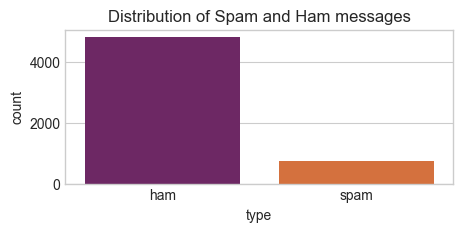

In [4]:
# Class distribution
plt.figure(figsize=(5, 2))
sns.countplot(x='type', data=df, palette='inferno')
plt.title('Distribution of Spam and Ham messages')
plt.show()

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

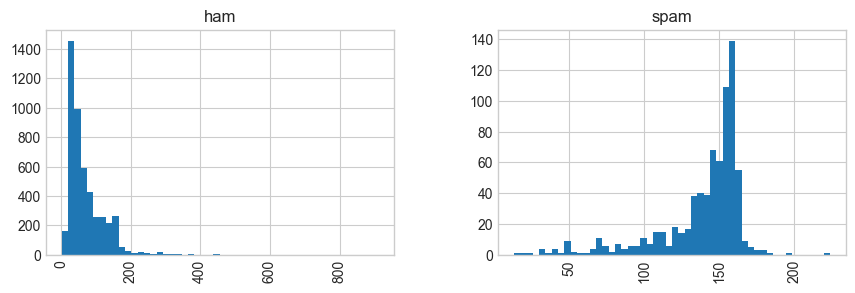

In [5]:
# Message Length Analysis
df['length'] = df['text'].apply(len)
df.hist(column='length', by='type', bins=50, figsize=(10, 3))

# 4. Prepare data by splitting the text documents into words and creating indicator features for frequent words

In [6]:
# Data Preperation - splitting text documents into words
def text_process(x):
    return x.split()

bow_transformer = CountVectorizer(analyzer=text_process).fit(df['text'])
print(len(bow_transformer.vocabulary_))
print(bow_transformer.get_feature_names_out()[0])
print(bow_transformer.get_feature_names_out()[8555])

15585
!
february


In [7]:
# Data preperation - creating indicator features for frequent words
messages_bow = bow_transformer.transform(df['text'])
tfidf_transformer = TfidfTransformer().fit(messages_bow)
messages_tfidf = tfidf_transformer.transform(messages_bow)
print(messages_tfidf.shape)

(5572, 15585)


# 5. Create training and test datasets

In [8]:
df['length'] = df['text'].apply(lambda x: len(x))
df = df[df['length'] > 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    5572 non-null   object
 1   text    5572 non-null   object
 2   length  5572 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 130.7+ KB


In [9]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['type'], test_size=0.2, random_state=42)

# 6. Transform training and test data using Bag of Words and TF-IDF

In [10]:
# For training data
messages_bow_train = bow_transformer.transform(X_train)
tfidf_transformer_train = TfidfTransformer().fit(messages_bow_train)
messages_tfidf_train = tfidf_transformer_train.transform(messages_bow_train)

# For test data
messages_bow_test = bow_transformer.transform(X_test)
tfidf_transformer_test = TfidfTransformer().fit(messages_bow_test)
messages_tfidf_test = tfidf_transformer_test.transform(messages_bow_test)

# 7. Train a model on the data

In [11]:
spam_detect_model = MultinomialNB().fit(messages_tfidf_train, y_train)

# 8. Evaluate the model performance

In [12]:
y_pred = spam_detect_model.predict(messages_tfidf_test)
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred))

Confusion Matrix
[[965   0]
 [ 70  80]]
Classification Report
              precision    recall  f1-score   support

         ham       0.93      1.00      0.96       965
        spam       1.00      0.53      0.70       150

    accuracy                           0.94      1115
   macro avg       0.97      0.77      0.83      1115
weighted avg       0.94      0.94      0.93      1115



# 9. Measure performance for classification


In [13]:
df_table = confusion_matrix(y_test, y_pred)
accuracy = (df_table[0,0] + df_table[1,1]) / (df_table[0,0] + df_table[0,1] + df_table[1,0] + df_table[1,1])
precision = df_table[1,1] / (df_table[1,1] + df_table[0,1])
recall = df_table[1,1] / (df_table[1,1] + df_table[1,0])
f1_score = (2 * precision * recall) / (precision + recall)

print("Accuracy : ", round(accuracy, 2))
print("Precision: ", round(precision, 2))
print("Recall   : ", round(recall, 2))
print("F1 score : ", round(f1_score, 2))

Accuracy :  0.94
Precision:  1.0
Recall   :  0.53
F1 score :  0.7


# Building a predictive system

In [14]:
# Function to predict if a message is spam or ham
def predict_message(message):
    # Transform the message using the same transformers
    message_bow = bow_transformer.transform([message])
    message_tfidf = tfidf_transformer.transform(message_bow)

    # Predict using the trained model
    prediction = spam_detect_model.predict(message_tfidf)
    return prediction[0]  # Return the predicted class

# Example usage
new_message = "hi my name is ashwin"
result = predict_message(new_message)

print(f"The message is classified as: {result}")

The message is classified as: ham
